# Part III: Clustering Steel Plate Faults after Dimensionality Reduction


## 1. Import Libraries


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


## 2. Load and Inspect the Dataset

The dataset is loaded from a local file when available. Otherwise, the source used in the supplied template is used.


In [2]:
DATA_URL = "https://raw.githubusercontent.com/wooihaw/datasets/main/steel_faults.csv"

try:
    df = pd.read_csv("steel_faults.csv")
except FileNotFoundError:
    df = pd.read_csv(DATA_URL)

df.head()


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Fault
0,42,50,270900,270944,267,17,44,24220,76,108,1687,1,0,80,0.0498,0.2415,0.1818,0.0047,0.4706,1.0000,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,1687,1,0,80,0.7647,0.3793,0.2069,0.0036,0.6000,0.9667,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,1623,1,0,100,0.9710,0.3426,0.3333,0.0037,0.7500,0.9474,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,1353,0,1,290,0.7287,0.4413,0.1556,0.0052,0.5385,1.0000,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,1353,0,1,185,0.0695,0.4486,0.0662,0.0126,0.2833,0.9885,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,Pastry


### Dataset Dimensions and Descriptive Statistics


In [3]:
print(f"Dataset dimensions: {df.shape[0]} rows x {df.shape[1]} columns")
print("The columns consist of 27 input features and 1 fault label.")

df.describe()


Dataset dimensions: 1941 rows x 28 columns
The columns consist of 27 input features and 1 fault label.


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,Length_of_Conveyer,TypeOfSteel_A300,TypeOfSteel_A400,Steel_Plate_Thickness,Edges_Index,Empty_Index,Square_Index,Outside_X_Index,Edges_X_Index,Edges_Y_Index,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas
count,1941.000000,1941.000000,1.941000e+03,1.941000e+03,1941.000000,1941.000000,1941.000000,1.941000e+03,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000,1941.000000
mean,571.136012,617.964451,1.650685e+06,1.650739e+06,1893.878413,111.855229,82.965997,2.063121e+05,84.548686,130.193715,1459.160227,0.400309,0.599691,78.737764,0.331715,0.414203,0.570767,0.033361,0.610529,0.813472,0.575734,2.492388,1.335686,1.403271,0.083288,-0.131305,0.585420
std,520.690671,497.627410,1.774578e+06,1.774590e+06,5168.459560,301.209187,426.482879,5.122936e+05,32.134276,18.690992,144.577823,0.490087,0.490087,55.086032,0.299712,0.137261,0.271058,0.058961,0.243277,0.234274,0.482352,0.788930,0.481612,0.454345,0.500868,0.148767,0.339452
min,0.000000,4.000000,6.712000e+03,6.724000e+03,2.000000,2.000000,1.000000,2.500000e+02,0.000000,37.000000,1227.000000,0.000000,0.000000,40.000000,0.000000,0.000000,0.008300,0.001500,0.014400,0.048400,0.000000,0.301000,0.301000,0.000000,-0.991000,-0.998900,0.119000
25%,51.000000,192.000000,4.712530e+05,4.712810e+05,84.000000,15.000000,13.000000,9.522000e+03,63.000000,124.000000,1358.000000,0.000000,0.000000,40.000000,0.060400,0.315800,0.361300,0.006600,0.411800,0.596800,0.000000,1.924300,1.000000,1.079200,-0.333300,-0.195000,0.248200
50%,435.000000,467.000000,1.204128e+06,1.204136e+06,174.000000,26.000000,25.000000,1.920200e+04,90.000000,127.000000,1364.000000,0.000000,1.000000,70.000000,0.227300,0.412100,0.555600,0.010100,0.636400,0.947400,1.000000,2.240600,1.176100,1.322200,0.095200,-0.133000,0.506300
75%,1053.000000,1072.000000,2.183073e+06,2.183084e+06,822.000000,84.000000,83.000000,8.301100e+04,106.000000,140.000000,1650.000000,1.000000,1.000000,80.000000,0.573800,0.501600,0.818200,0.023500,0.800000,1.000000,1.000000,2.914900,1.518500,1.732400,0.511600,-0.066600,0.999800
max,1705.000000,1713.000000,1.298766e+07,1.298769e+07,152655.000000,10449.000000,18152.000000,1.159141e+07,203.000000,253.000000,1794.000000,1.000000,1.000000,300.000000,0.995200,0.943900,1.000000,0.875900,1.000000,1.000000,1.000000,5.183700,3.074100,4.258700,0.991700,0.642100,1.000000


### Fault Types


In [4]:
fault_counts = df["Fault"].value_counts()

print(f"Number of fault types: {fault_counts.size}")
fault_counts.to_frame(name="Samples")


Number of fault types: 7


,Samples
Fault,
Other_Faults,673
Bumps,402
K_Scatch,391
Z_Scratch,190
Pastry,158
Stains,72
Dirtiness,55


### Missing Values


In [5]:
missing_values = df.isna().sum()

print(f"Total missing values: {missing_values.sum()}")
print(f"Columns with missing values: {(missing_values > 0).sum()}")


Total missing values: 0
Columns with missing values: 0


The dataset contains 1941 observations, 7 fault types, and no missing values. Hence, no imputation is required.


## 3. Separate the Features and Label


In [6]:
X = df.drop(columns="Fault")
y = df["Fault"]

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")


X shape: (1941, 27)
y shape: (1941,)


`X` contains the 27 numeric input features. `y` stores the fault labels for reference and visualization, but not used to fit PCA or K-Means.


## 4. Dimensionality Reduction with PCA

PCA reduces the 27 input features to 5 principal components. The original feature scales are retained to preserve the variance structure required by this analysis.


In [7]:
N_COMPONENTS = 5

pca = PCA(n_components=N_COMPONENTS)
X_pca = pca.fit_transform(X)

explained_variance = pd.DataFrame({
    "Principal Component": [f"PC{i}" for i in range(1, N_COMPONENTS + 1)],
    "Explained Variance (%)": pca.explained_variance_ratio_ * 100,
    "Cumulative Variance (%)": np.cumsum(pca.explained_variance_ratio_) * 100,
})

print(f"Original dimensions: {X.shape[1]}")
print(f"Reduced dimensions: {X_pca.shape[1]}")
explained_variance.round(6)


Original dimensions: 27
Reduced dimensions: 5


,Principal Component,Explained Variance (%),Cumulative Variance (%)
0,PC1,95.999598,95.999598
1,PC2,4.000375,99.999973
2,PC3,0.000019,99.999992
3,PC4,0.000007,99.999999
4,PC5,0.000000,100.000000


The five components retain approximately 100% of the total variance. PC1 and PC2 account for approximately 96.0% and 4.0%, respectively.


### Most Important Original Feature for Each Principal Component


In [8]:
absolute_loadings = np.abs(pca.components_)
feature_indices = absolute_loadings.argmax(axis=1)

important_features = pd.DataFrame({
    "Principal Component": [f"PC{i}" for i in range(1, N_COMPONENTS + 1)],
    "Feature Index": feature_indices,
    "Most Important Feature": X.columns[feature_indices],
    "Absolute Loading": absolute_loadings[
        np.arange(N_COMPONENTS), feature_indices
    ],
})

important_features.round({"Absolute Loading": 6})


,Principal Component,Feature Index,Most Important Feature,Absolute Loading
0,PC1,3,Y_Maximum,0.707108
1,PC2,7,Sum_of_Luminosity,0.999950
2,PC3,4,Pixels_Areas,0.933196
3,PC4,0,X_Minimum,0.704495
4,PC5,10,Length_of_Conveyer,0.980629


The largest absolute loading on PC1 belongs to `Y_Maximum`, while PC2 is dominated by `Sum_of_Luminosity`. Absolute loadings are used because the sign of a principal component can reverse without changing its meaning.


## 5. K-Means Clustering

K-Means is fitted to the five PCA components with `k = 7`, corresponding to the seven known fault types. A fixed random state and multiple initializations make the result reproducible and reduce sensitivity to poor starting centroids.


In [9]:
N_CLUSTERS = 7

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    init="k-means++",
    n_init=20,
    random_state=42,
)
cluster_labels = kmeans.fit_predict(X_pca)

cluster_counts = (
    pd.Series(cluster_labels, name="Cluster")
    .value_counts()
    .sort_index()
    .rename("Samples")
    .to_frame()
)

print(f"Number of clusters: {cluster_counts.shape[0]}")
cluster_counts


Number of clusters: 7


,Samples
Cluster,
0,393
1,695
2,29
3,164
4,519
5,100
6,41


### Silhouette Coefficient


In [10]:
silhouette = silhouette_score(X_pca, cluster_labels)
print(f"Silhouette Coefficient: {silhouette:.3f}")


Silhouette Coefficient: 0.536


The Silhouette Coefficient is **0.536**, indicating moderate separation between clusters. This is consistent with the expected value of approximately 0.5.


## 6. Before and After Clustering


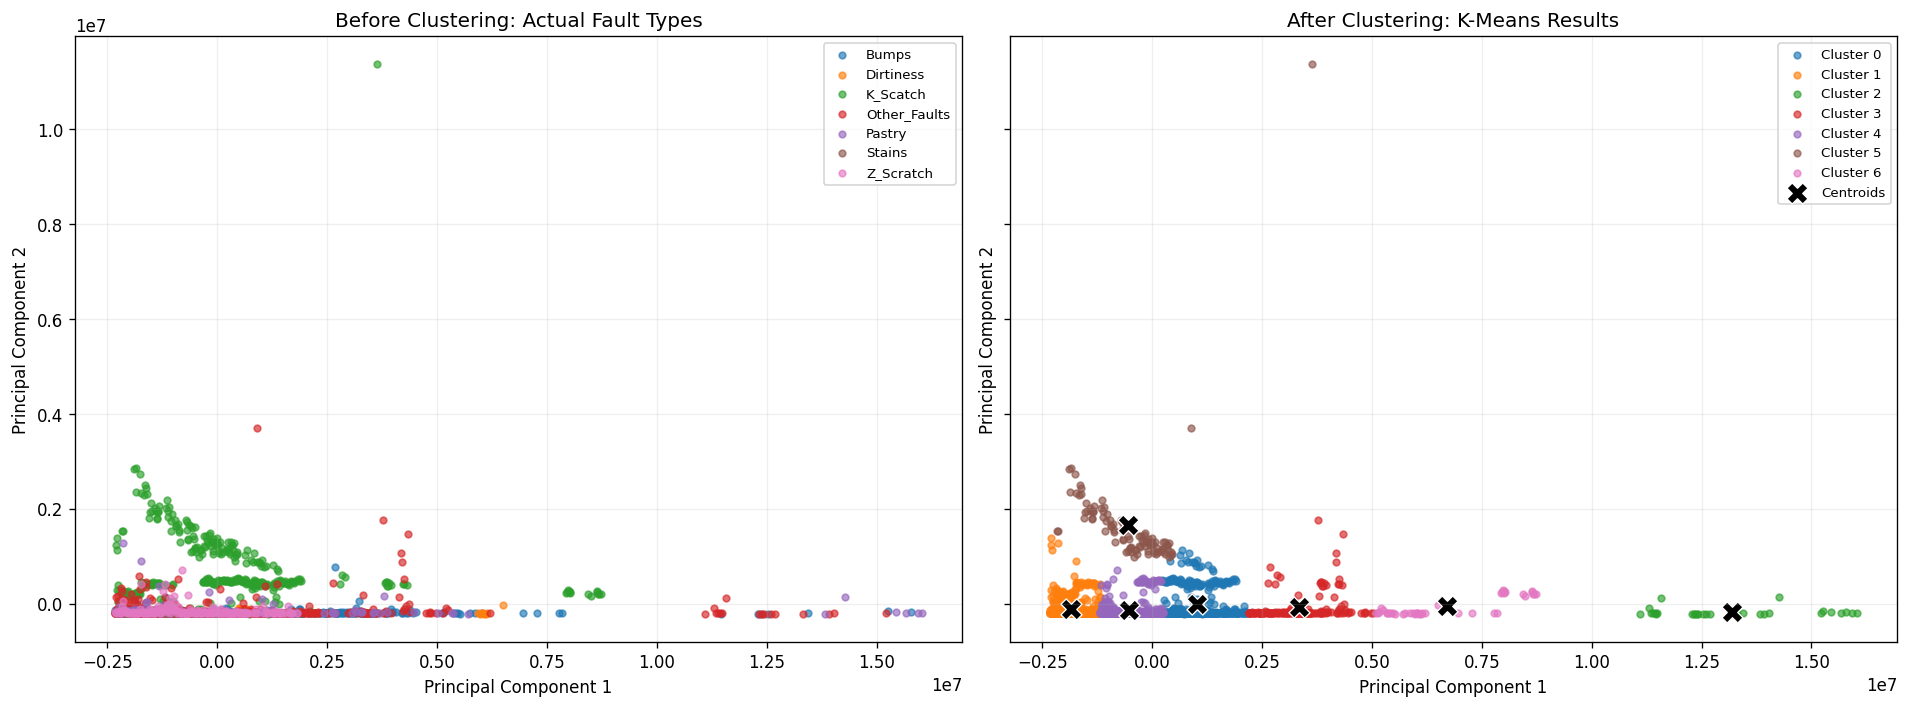

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True, sharey=True)
colors = plt.get_cmap("tab10").colors

# Before clustering: actual fault types shown on the first two PCA dimensions.
for color, fault in zip(colors, sorted(y.unique())):
    mask = y.eq(fault).to_numpy()
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=16,
        alpha=0.65,
        color=color,
        label=fault,
    )

# After clustering: K-Means assignments on the same PCA dimensions.
for cluster, color in zip(range(N_CLUSTERS), colors):
    mask = cluster_labels == cluster
    axes[1].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        s=16,
        alpha=0.65,
        color=color,
        label=f"Cluster {cluster}",
    )

centroids = kmeans.cluster_centers_
axes[1].scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=160,
    color="black",
    edgecolor="white",
    linewidth=0.8,
    label="Centroids",
)

axes[0].set_title("Before Clustering: Actual Fault Types")
axes[1].set_title("After Clustering: K-Means Results")

for ax in axes:
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, frameon=True)
    ax.ticklabel_format(style="sci", axis="both", scilimits=(0, 0))

plt.tight_layout()
plt.show()


Both plots use the same PCA coordinates. The actual labels on the left are shown only for comparison and were not used by K-Means. The overlap between groups agrees with the moderate Silhouette Coefficient. Cluster numbers are arbitrary and do not correspond directly to the fault names.
